<a href="https://colab.research.google.com/github/tanuku-srivalli/CUSTOMER-LIFETIME-VALUE-PREDICTION-MODEL/blob/main/DA_Project_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***CUSTOMER LIFETIME VALUE PREDICTION MODEL***

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [ ]:
df = pd.read_csv('WA_Fn-UseC_-Marketing-Customer-Value-Analysis.csv')

In [ ]:
print("Initial Data Shape:", df.shape)
print("\n--- Initial Columns and Data Types ---")
df.info(verbose=False)

Initial Data Shape: (9134, 24)

--- Initial Columns and Data Types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9134 entries, 0 to 9133
Columns: 24 entries, Customer to Vehicle Size
dtypes: float64(2), int64(6), object(16)
memory usage: 1.7+ MB


In [ ]:
df.columns = df.columns.str.replace(' ', '_')

In [ ]:
columns_to_drop = ['Customer', 'Effective_To_Date', 'Policy']
df = df.drop(columns=columns_to_drop, errors='ignore')

print("\n--- Data after dropping columns ---")
print(df.head(2))


--- Data after dropping columns ---
        State  Customer_Lifetime_Value Response  Coverage Education  \
0  Washington              2763.519279       No     Basic  Bachelor   
1     Arizona              6979.535903       No  Extended  Bachelor   

  EmploymentStatus Gender  Income Location_Code Marital_Status  ...  \
0         Employed      F   56274      Suburban        Married  ...   
1       Unemployed      F       0      Suburban         Single  ...   

   Months_Since_Last_Claim  Months_Since_Policy_Inception  \
0                       32                              5   
1                       13                             42   

   Number_of_Open_Complaints  Number_of_Policies     Policy_Type  \
0                          0                   1  Corporate Auto   
1                          0                   8   Personal Auto   

  Renew_Offer_Type Sales_Channel Total_Claim_Amount  Vehicle_Class  \
0           Offer1         Agent         384.811147   Two-Door Car   
1     

In [ ]:
Y = df['Customer_Lifetime_Value']

In [ ]:
X = df.drop('Customer_Lifetime_Value', axis=1)

In [ ]:
Y_log = np.log1p(Y)
print("\nTarget variable (Y) is log-transformed for better modeling.")


Target variable (Y) is log-transformed for better modeling.


In [ ]:
numerical_features = [col for col in X.columns if X[col].dtype != 'object']
categorical_features = [col for col in X.columns if X[col].dtype == 'object']

print(f"\nNumerical Features ({len(numerical_features)}): {numerical_features}")
print(f"Categorical Features ({len(categorical_features)}): {categorical_features}")


Numerical Features (7): ['Income', 'Monthly_Premium_Auto', 'Months_Since_Last_Claim', 'Months_Since_Policy_Inception', 'Number_of_Open_Complaints', 'Number_of_Policies', 'Total_Claim_Amount']
Categorical Features (13): ['State', 'Response', 'Coverage', 'Education', 'EmploymentStatus', 'Gender', 'Location_Code', 'Marital_Status', 'Policy_Type', 'Renew_Offer_Type', 'Sales_Channel', 'Vehicle_Class', 'Vehicle_Size']


In [ ]:
numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough' # Keep any columns not explicitly transformed
)

In [ ]:
X_processed = preprocessor.fit_transform(X)

print(f"\nShape of Processed Features (X_processed): {X_processed.shape}")
print(f"Total Features after One-Hot Encoding: {X_processed.shape[1]}")


Shape of Processed Features (X_processed): (9134, 55)
Total Features after One-Hot Encoding: 55


In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X_processed, Y_log, # Use the log-transformed target variable!
    test_size=0.2,
    random_state=42
)

print("\n--- Final Data Ready for Phase 2 (Model Training) ---")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Y_train shape: {Y_train.shape}")
print(f"Y_test shape: {Y_test.shape}")


--- Final Data Ready for Phase 2 (Model Training) ---
X_train shape: (7307, 55)
X_test shape: (1827, 55)
Y_train shape: (7307,)
Y_test shape: (1827,)


In [ ]:
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error

# --- 1. Model Training (XGBoost Regressor) ---

print("--- Starting XGBoost Model Training ---")

# Initialize the XGBoost Regressor
# We're using a common objective for regression and a fixed random state for reproducibility.
xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror', # Standard objective for regression tasks
    n_estimators=500,             # Number of boosting rounds (trees)
    learning_rate=0.05,           # Step size shrinkage to prevent overfitting
    max_depth=5,                  # Maximum depth of a tree
    random_state=42,              # For reproducible results
    n_jobs=-1                     # Use all available CPU cores
)

# Train the model using the log-transformed target (Y_train)
xgb_model.fit(X_train, Y_train)

print("XGBoost Model Training Complete.")

# --- 2. Model Prediction ---

# Predict the LTV on the test set.
# NOTE: These predictions are in the LOG-TRANSFORMED space.
Y_pred_log = xgb_model.predict(X_test)

# Convert the predictions and the actual test values back to the original dollar scale
# np.expm1(x) is mathematically equivalent to (e^x) - 1, reversing the np.log1p(x) applied in Phase 1.
Y_pred_original = np.expm1(Y_pred_log)
Y_test_original = np.expm1(Y_test) # Remember to transform the actual values too for evaluation

# --- 3. Model Validation (Metrics) ---

print("\n--- Model Validation Metrics (Original Dollar Scale) ---")

# Mean Absolute Error (MAE)
# MAE is easy to interpret: on average, how far off is the prediction in dollars.
mae = mean_absolute_error(Y_test_original, Y_pred_original)
print(f"Mean Absolute Error (MAE): ${mae:,.2f}")

# Root Mean Squared Error (RMSE)
# RMSE is useful as it penalizes larger errors more heavily.
rmse = np.sqrt(mean_squared_error(Y_test_original, Y_pred_original))
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")

# R-squared (R2) score - Measures the proportion of variance explained by the model
r2 = xgb_model.score(X_test, Y_test)
print(f"R-squared (R2) Score: {r2:.4f}")

feature_names = xgb_model.get_booster().feature_names

print("\nPhase 2 Complete. Proceed to Phase 3 for Analysis and Deliverables.")

--- Starting XGBoost Model Training ---
XGBoost Model Training Complete.

--- Model Validation Metrics (Original Dollar Scale) ---
Mean Absolute Error (MAE): $1,458.94
Root Mean Squared Error (RMSE): $4,170.68
R-squared (R2) Score: 0.9079

Phase 2 Complete. Proceed to Phase 3 for Analysis and Deliverables.



--- Predicted LTV Segments ---
LTV_Segment
Medium-Value              4566
Low-Value (Bottom 25%)    2284
High-Value (Top 25%)      2284
Name: count, dtype: int64


/tmp/ipython-input-3200295419.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features.values, y=top_features.index, palette="viridis")


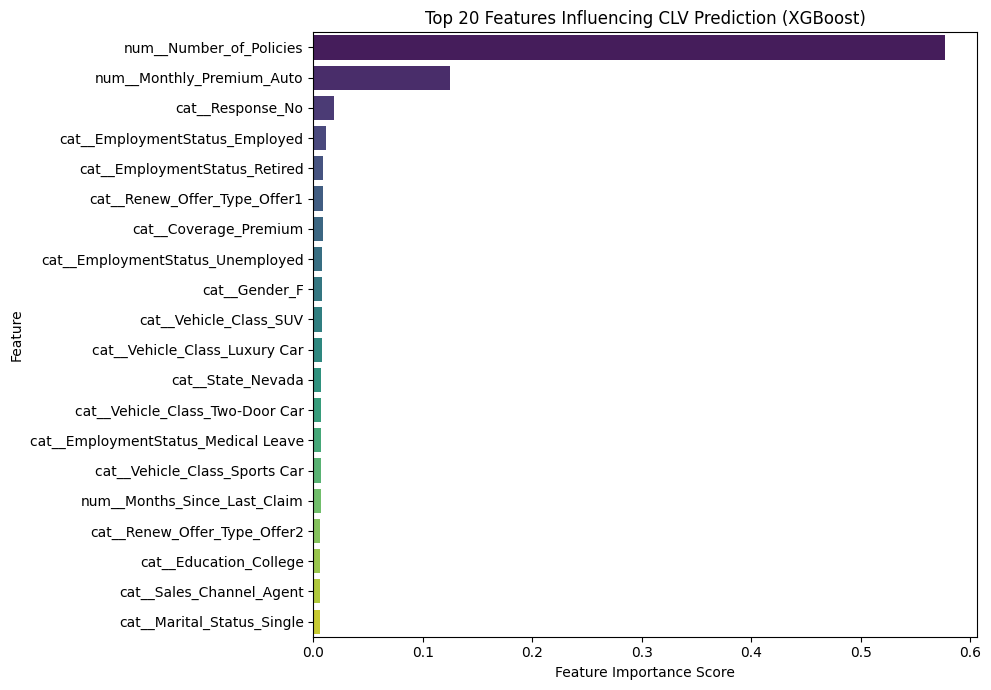

/tmp/ipython-input-3200295419.py:73: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_clv_output['Actual_LTV'] = Y.values
/tmp/ipython-input-3200295419.py:86: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features.values, y=top_features.index, palette="viridis")



DELIVERABLE: 'Final_CLV_Prediction.csv' created.
DELIVERABLE: 'clv_xgb_model.joblib' (Trained Model) saved.
DELIVERABLE: 'CLV_Feature_Importance_Chart.png' saved.


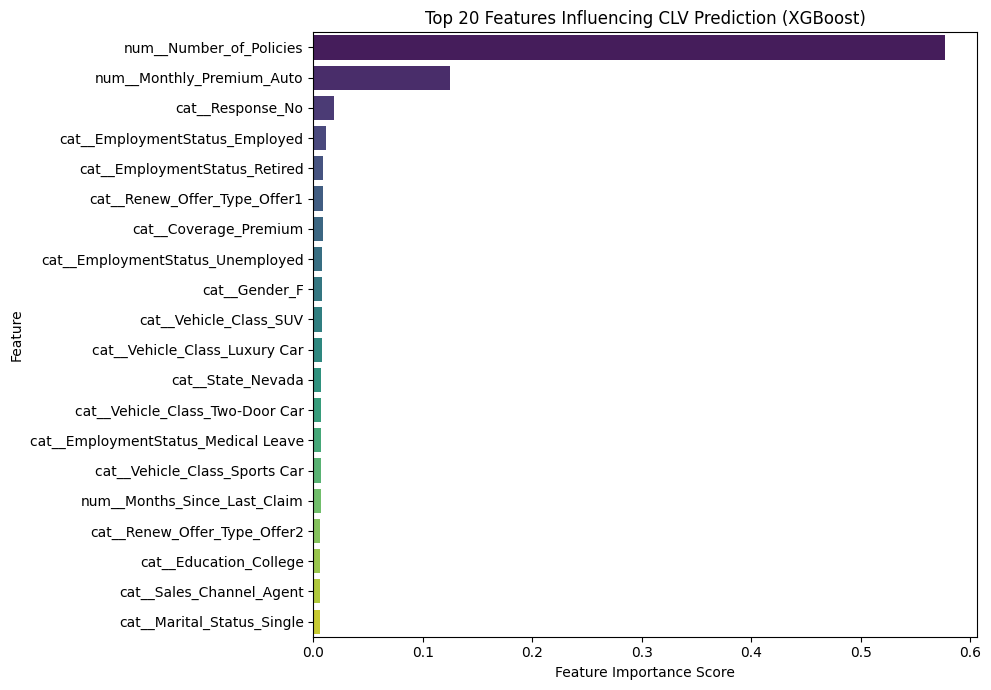

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib


# --- 1. Final Prediction and Reversal ---

# Predict LTV for ALL processed customers
Y_all_pred_log = xgb_model.predict(X_processed)

# Convert predictions back to the original dollar scale (using expm1)
Y_pred_final = np.expm1(Y_all_pred_log)

# --- 2. Customer Segmentation ---

# Combine predictions with the original customer data for segmentation
customer_data_with_pred = X.copy()
customer_data_with_pred['Predicted_LTV'] = Y_pred_final

# Create LTV Segments (Example: Quartiles)
# High-Value: Top 25% of predicted LTV
# Medium-Value: Middle 50%
# Low-Value: Bottom 25%

# Calculate quartiles for segmentation thresholds
q75, q25 = np.percentile(Y_pred_final, [75, 25])
q50 = np.percentile(Y_pred_final, 50)

def segment_customer(ltv):
    if ltv >= q75:
        return 'High-Value (Top 25%)'
    elif ltv >= q25:
        return 'Medium-Value'
    else:
        return 'Low-Value (Bottom 25%)'

customer_data_with_pred['LTV_Segment'] = customer_data_with_pred['Predicted_LTV'].apply(segment_customer)

print("\n--- Predicted LTV Segments ---")
print(customer_data_with_pred['LTV_Segment'].value_counts())

# --- 3. Feature Importance Analysis (Visualization) ---

# Get the feature names after one-hot encoding
# The preprocessor contains the OHE step; we extract feature names from it.
feature_names_out = preprocessor.get_feature_names_out()

# Match feature importances with names
feature_importances = pd.Series(xgb_model.feature_importances_, index=feature_names_out)

# Select top N features for visualization
top_n = 20
top_features = feature_importances.nlargest(top_n)

plt.figure(figsize=(10, 7))
sns.barplot(x=top_features.values, y=top_features.index, palette="viridis")
plt.title(f'Top {top_n} Features Influencing CLV Prediction (XGBoost)')
plt.xlabel('Feature Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


# --- 4. Deliverables Generation ---

## A. Final LTV Prediction CSV
# Merge back the original Customer ID if available, otherwise use index.
# Since we dropped 'Customer' in Phase 1, we use the original index.
final_clv_output = customer_data_with_pred[['Predicted_LTV', 'LTV_Segment']]

final_clv_output['Actual_LTV'] = Y.values

# Sort by highest predicted LTV
final_clv_output = final_clv_output.sort_values(by='Predicted_LTV', ascending=False)
final_clv_output.to_csv('Final_CLV_Prediction.csv', index=True) # Use index as customer identifier
print("\nDELIVERABLE: 'Final_CLV_Prediction.csv' created.")

## B. Trained Model (Saving)
joblib.dump(xgb_model, 'clv_xgb_model.joblib')
print("DELIVERABLE: 'clv_xgb_model.joblib' (Trained Model) saved.")

## C. Visualizations (Saving)
plt.figure(figsize=(10, 7))
sns.barplot(x=top_features.values, y=top_features.index, palette="viridis")
plt.title(f'Top {top_n} Features Influencing CLV Prediction (XGBoost)')
plt.xlabel('Feature Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('CLV_Feature_Importance_Chart.png')
print("DELIVERABLE: 'CLV_Feature_Importance_Chart.png' saved.")

In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# --- ASSUMPTIONS (Ensure these variables are loaded/available) ---
# Y_test: The actual Customer Lifetime Values from the test set (log-transformed)
# Y_pred_log: The predicted CLV values from your model (log-transformed)

# --- 1. Reverse Log Transformation ---
# np.expm1(x) is used to reverse the np.log1p(x) transformation

Y_test_original = np.expm1(Y_test)         # Actual LTV in dollar scale
Y_pred_original = np.expm1(Y_pred_log)     # Predicted LTV in dollar scale

# --- 2. Calculate Metrics ---

# Mean Absolute Error (MAE)
# Easy to interpret: average difference between prediction and actual value.
mae = mean_absolute_error(Y_test_original, Y_pred_original)

# Root Mean Squared Error (RMSE)
# Calculate MSE first, then take the square root.
mse = mean_squared_error(Y_test_original, Y_pred_original)
rmse = np.sqrt(mse)

# --- 3. Output the Values ---
print("\n--- Model Validation Results (Original Dollar Scale) ---")
print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")

# Store the final values for easy copy/pasting into your report
report_mae = round(mae, 2)
report_rmse = round(rmse, 2)

print("\nReport Values Saved:")
print(f"MAE: {report_mae}")
print(f"RMSE: {report_rmse}")


--- Model Validation Results (Original Dollar Scale) ---
Mean Absolute Error (MAE): $1,458.94
Root Mean Squared Error (RMSE): $4,170.68

Report Values Saved:
MAE: 1458.94
RMSE: 4170.68
